<a href="https://colab.research.google.com/github/kimhj5125/speaker-recognition/blob/main/Speaker_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
!pip install noisereduce

In [43]:
# ============================================================
# [Cell 0] Common Configuration: Imports / Constants / Functions
# ============================================================

# ── Imports ──────────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import noisereduce as nr
import kagglehub

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.manifold import TSNE

# ── Constants ─────────────────────────────────────────────────────
SR            = 16000
N_MFCC        = 20
DRIVE_DIR     = "/content/drive/MyDrive/Speech_Project"
NOISE_FOLDERS = ['_background_noise_', 'other']
SPEAKER_NAMES = [
    "Benjamin_Netanyau",
    "Jens_Stoltenberg",
    "Julia_Gillard",
    "Margaret_Tatcher",
    "Nelson_Mandela",
]

# ── Google Drive Mount & Common Functions ─────────────────────────────────────────────────
drive.mount('/content/drive')

def extract_features(audio_data, sr=SR, n_mfcc=N_MFCC):
    """
    Extract a 25-dimensional feature vector from audio data:
      - MFCC             : n_mfcc coefficients (Default: 20)
      - Spectral Features: Centroid, Rolloff, Bandwidth (3)
      - Pitch (f0)       : Fundamental frequency (1)
      - Energy (RMS)     : Root Mean Square energy (1)
    """
    features = []
    for i, signal in enumerate(audio_data):
        vec = []

        # MFCC (20-dim)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
        vec.extend(np.mean(mfcc, axis=1))

        # Spectral features (3-dim)
        vec.append(np.mean(librosa.feature.spectral_centroid(y=signal, sr=sr)))
        vec.append(np.mean(librosa.feature.spectral_rolloff(y=signal, sr=sr)))
        vec.append(np.mean(librosa.feature.spectral_bandwidth(y=signal, sr=sr)))

        # Pitch / f0 (1-dim)
        f0 = librosa.yin(signal,
                 fmin=librosa.note_to_hz('C2'),
                 fmax=librosa.note_to_hz('C7'),
                 sr=sr)
        vec.append(np.nanmean(f0) if not np.all(np.isnan(f0)) else 0.0)

        # RMS Energy (1-dim)
        vec.append(np.mean(librosa.feature.rms(y=signal)))

        features.append(vec)

        if (i + 1) % 500 == 0 or (i + 1) == len(audio_data):
            print(f"  └ Progress: {i+1}/{len(audio_data)}")

    return np.array(features)


def save_npy(data_dict, save_dir=DRIVE_DIR):
    """Save a dictionary of {filename: array} to Google Drive."""
    os.makedirs(save_dir, exist_ok=True)
    for name, arr in data_dict.items():
        np.save(os.path.join(save_dir, f"{name}.npy"), arr)
    print(f"[INFO] Save completed successfully to: {save_dir}")


def load_npy(*names, load_dir=DRIVE_DIR):
    """Load .npy files sequentially from Google Drive."""
    return [np.load(os.path.join(load_dir, f"{n}.npy")) for n in names]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
# ============================================================
# [Cell 1] Data Loading
# ============================================================

path = kagglehub.dataset_download("kongaevans/speaker-recognition-dataset")

# Resolve kagglehub nested directory structure
if not os.path.exists(os.path.join(path, SPEAKER_NAMES[0])):
    path = [f.path for f in os.scandir(path) if f.is_dir()][0]
actual_path = path

print(f"[INFO] Data path: {actual_path}")
print(f"[INFO] Internal directories: {os.listdir(actual_path)}")

Using Colab cache for faster access to the 'speaker-recognition-dataset' dataset.
[INFO] Data path: /kaggle/input/speaker-recognition-dataset/16000_pcm_speeches
[INFO] Internal directories: ['Nelson_Mandela', 'Benjamin_Netanyau', 'other', '_background_noise_', 'tf_Wav_reader.py', 'Magaret_Tarcher', 'Jens_Stoltenberg', 'Julia_Gillard']


In [45]:
# ============================================================
# [Cell 2] EDA — Data Specification & Quality Diagnosis
# ============================================================

all_folders = os.listdir(actual_path)
target_speakers = [
    f for f in all_folders
    if os.path.isdir(os.path.join(actual_path, f)) and f not in NOISE_FOLDERS
]

rows = []
for folder in target_speakers + NOISE_FOLDERS:
    full_path = os.path.join(actual_path, folder)
    if not os.path.exists(full_path):
        fallback = glob.glob(os.path.join(actual_path, "**", folder), recursive=True)
        if fallback:
            full_path = fallback[0]
        else:
            continue

    wav_files = glob.glob(os.path.join(full_path, "**/*.wav"), recursive=True)
    durations = []
    for f in wav_files:
        try:
            durations.append(librosa.get_duration(path=f))
        except Exception:
            pass

    if durations:
        min_d, max_d = min(durations), max(durations)
        status = "Perfect (1.0s)" if (round(min_d, 2) == 1.0 and round(max_d, 2) == 1.0) else "Variable"
    else:
        min_d = max_d = 0
        status = "No Data"

    rows.append({
        "Folder / Speaker"      : folder,
        "Type"                  : "Noise/Other" if folder in NOISE_FOLDERS else "Target Speaker",
        "File Count"            : len(wav_files),
        "Min Duration (s)"      : round(min_d, 2),
        "Max Duration (s)"      : round(max_d, 2),
        "Status (All 1.0 s?)"   : status,
    })

df_meta = pd.DataFrame(rows)
display(df_meta)

,Folder / Speaker,Type,File Count,Min Duration (s),Max Duration (s),Status (All 1.0 s?)
0,Nelson_Mandela,Target Speaker,1500,1.00,1.00,Perfect (1.0s)
1,Benjamin_Netanyau,Target Speaker,1500,1.00,1.00,Perfect (1.0s)
2,Magaret_Tarcher,Target Speaker,1500,1.00,1.00,Perfect (1.0s)
3,Jens_Stoltenberg,Target Speaker,1500,1.00,1.00,Perfect (1.0s)
4,Julia_Gillard,Target Speaker,1501,1.00,1.00,Perfect (1.0s)
5,_background_noise_,Noise/Other,4,16.29,95.18,Variable
6,other,Noise/Other,2,60.00,61.25,Variable


In [47]:
# ============================================================
# [Cell 3] Data Preprocessing: Noise Reduction, Splitting, & Saving
# ============================================================

# Build Noise Profile
noise_samples = []
for folder in NOISE_FOLDERS:
    folder_path = os.path.join(actual_path, folder)
    if not os.path.exists(folder_path):
        continue
    for f in glob.glob(os.path.join(folder_path, "**/*.wav"), recursive=True):
        try:
            y, _ = librosa.load(f, sr=SR, duration=10.0)
            noise_samples.append(y)
        except Exception:
            pass

if noise_samples:
    combined_noise = np.concatenate(noise_samples)
    print(f"[INFO] Noise profile constructed ({len(combined_noise)/SR:.2f} seconds)")
else:
    combined_noise = None
    print("[WARN] No noise files found. Proceeding without noise reduction.")

# Audio Loading & Noise Reduction
print("\n[INFO] Starting audio preprocessing...")
audio_signals, labels = [], []
for label_idx, speaker in enumerate(target_speakers):
    speaker_path = os.path.join(actual_path, speaker)
    wav_files = glob.glob(os.path.join(speaker_path, "*.wav"))
    print(f" └ [{speaker}] Applying noise reduction... ({len(wav_files)} files)")
    for f in wav_files:
        try:
            y, _ = librosa.load(f, sr=SR, duration=1.0)
            if len(y) < SR:
                y = librosa.util.fix_length(y, size=SR)
            if combined_noise is not None:
                y = nr.reduce_noise(y=y, sr=SR, y_noise=combined_noise,
                                    stationary=True, n_jobs=1)
            audio_signals.append(y)
            labels.append(label_idx)
        except Exception as e:
            print(f"[WARN] Excluded file: {f} -> {e}")

X_audio = np.array(audio_signals)
y_audio = np.array(labels)
print(f"\n[INFO] Preprocessing completed successfully: {X_audio.shape}")

# Dataset Splitting: Train(60%) / Val(20%) / Test(20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_audio, y_audio, test_size=0.20, random_state=42, stratify=y_audio
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"\n[INFO] Dataset Split Summary:")
print(f"  Train      (60%) : {X_train.shape}")
print(f"  Validation (20%) : {X_val.shape}")
print(f"  Test       (20%) : {X_test.shape}")

# Export Arrays to Google Drive
save_npy({
    "X_train": X_train, "y_train": y_train,
    "X_val"  : X_val,   "y_val"  : y_val,
    "X_test" : X_test,  "y_test" : y_test,
})

[INFO] Noise profile constructed (60.00 seconds)

[INFO] Starting audio preprocessing...
 └ [Nelson_Mandela] Applying noise reduction... (1500 files)
 └ [Benjamin_Netanyau] Applying noise reduction... (1500 files)
 └ [Magaret_Tarcher] Applying noise reduction... (1500 files)
 └ [Jens_Stoltenberg] Applying noise reduction... (1500 files)
 └ [Julia_Gillard] Applying noise reduction... (1501 files)

[INFO] Preprocessing completed successfully: (7501, 16000)

[INFO] Dataset Split Summary:
  Train      (60%) : (4500, 16000)
  Validation (20%) : (1500, 16000)
  Test       (20%) : (1501, 16000)
[INFO] Save completed successfully to: /content/drive/MyDrive/Speech_Project


In [48]:
# ============================================================
# [Cell 4] Training Set: Feature Extraction & Scaling
# ============================================================

X_train_raw, y_train = load_npy("X_train", "y_train")

print("[INFO] Extracting features from Training set...")
X_train_features = extract_features(X_train_raw)

# Fit and transform the scaler based ONLY on the Training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)

save_npy({"X_train_features": X_train_features, "X_train_scaled": X_train_scaled})
print(f"[INFO] Training set feature extraction completed: {X_train_features.shape} (25-dim)")

[INFO] Extracting features from Training set...
  └ Progress: 500/4500
  └ Progress: 1000/4500
  └ Progress: 1500/4500
  └ Progress: 2000/4500
  └ Progress: 2500/4500
  └ Progress: 3000/4500
  └ Progress: 3500/4500
  └ Progress: 4000/4500
  └ Progress: 4500/4500
[INFO] Save completed successfully to: /content/drive/MyDrive/Speech_Project
[INFO] Training set feature extraction completed: (4500, 25) (25-dim)


In [49]:
# ============================================================
# [Cell 5] Model Training: RF / Linear SVM / RBF SVM
# ============================================================

X_train_features, X_train_scaled, y_train = load_npy("X_train_features", "X_train_scaled", "y_train")

# Model 1: Random Forest
print("[Model 1] Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_features, y_train)
print("└ Training completed.")

# Model 2: Linear SVM
print("[Model 2] Training Linear SVM...")
linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train_scaled, y_train)
print("└ Training completed.")

# Model 3: RBF SVM (Baseline configuration; optimized during Validation phase)
print("[Model 3] Training RBF SVM (Baseline: C=1.0, gamma='scale')")
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
rbf_svm.fit(X_train_scaled, y_train)
print("└ Training completed.")

[Model 1] Training Random Forest...
└ Training completed.
[Model 2] Training Linear SVM...
└ Training completed.
[Model 3] Training RBF SVM (Baseline: C=1.0, gamma='scale')
└ Training completed.


In [50]:
# ============================================================
# [Cell 6] Validation Set: Feature Extraction & Scaling
# ============================================================

X_val_raw, y_val = load_npy("X_val", "y_val")

print("[INFO] Extracting features from Validation set...")
X_val_features = extract_features(X_val_raw)

# Transform using the scaler already fitted on the Training set
X_val_scaled = scaler.transform(X_val_features)

save_npy({"X_val_features": X_val_features, "X_val_scaled": X_val_scaled})
print(f"[INFO] Validation set feature extraction completed: {X_val_features.shape}")

[INFO] Extracting features from Validation set...
  └ Progress: 500/1500
  └ Progress: 1000/1500
  └ Progress: 1500/1500
[INFO] Save completed successfully to: /content/drive/MyDrive/Speech_Project
[INFO] Validation set feature extraction completed: (1500, 25)


In [51]:
# ============================================================
# [Cell 7] Validation: Grid Search for RBF SVM Hyperparameters
# ============================================================

X_val_scaled, y_val     = load_npy("X_val_scaled", "y_val")
X_train_scaled, y_train = load_npy("X_train_scaled", "y_train")

C_list     = [0.1, 1, 10, 100]
gamma_list = [0.001, 0.01, 0.1, 1]

best_val_acc = 0.0
best_C = best_gamma = None
grid_rows = []

for C in C_list:
    for gamma in gamma_list:
        m = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_val, m.predict(X_val_scaled))

        # Append rows to construct the grid search table
        grid_rows.append({
            "C"          : C,
            "gamma"      : gamma,
            "Val Acc (%)": round(acc * 100, 2)
        })

        if acc > best_val_acc:
            best_val_acc, best_C, best_gamma = acc, C, gamma

# Display Grid Search results as a DataFrame table
df_grid = pd.DataFrame(grid_rows)
display(df_grid)

print(f"\n[Optimal Configuration] Best C={best_C}, gamma={best_gamma} → Val Acc: {best_val_acc*100:.2f}%")

# Retrain the final RBF SVM using the optimal hyperparameters
best_rbf_svm = SVC(kernel='rbf', C=best_C, gamma=best_gamma, random_state=42)
best_rbf_svm.fit(X_train_scaled, y_train)
print("[Model 3] Final RBF SVM training completed with optimal parameters.")

,C,gamma,Val Acc (%)
0,0.1,0.001,83.93
1,0.1,0.010,95.07
2,0.1,0.100,97.67
3,0.1,1.000,31.67
4,1.0,0.001,94.73
5,1.0,0.010,97.93
6,1.0,0.100,98.80
7,1.0,1.000,50.47
8,10.0,0.001,97.07
9,10.0,0.010,98.40



[Optimal Configuration] Best C=100, gamma=0.1 → Val Acc: 99.07%
[Model 3] Final RBF SVM training completed with optimal parameters.


In [52]:
# ============================================================
# [Cell 8] Validation: Model Performance Comparison
# ============================================================

X_val_features, X_val_scaled, y_val = load_npy("X_val_features", "X_val_scaled", "y_val")

rf_acc     = accuracy_score(y_val, rf.predict(X_val_features))
linear_acc = linear_svm.score(X_val_scaled, y_val)
rbf_acc    = best_rbf_svm.score(X_val_scaled, y_val)

print("Validation Set Model Performance Comparison")
print(f"  Random Forest                        : {rf_acc*100:.2f}%")
print(f"  Linear SVM                           : {linear_acc*100:.2f}%")
print(f"  RBF SVM (C={best_C}, gamma={best_gamma}) : {rbf_acc*100:.2f}%")

Validation Set Model Performance Comparison
  Random Forest                        : 97.20%
  Linear SVM                           : 97.73%
  RBF SVM (C=100, gamma=0.1) : 99.07%


NOTE: The extracted audio features demonstrate high linear separability in the 25-dimensional space, yielding robust and consistent performance across all linear and non-linear classifiers.
Therefore, all three models proceed to the final evaluation stage.

In [53]:
# ============================================================
# [Cell 9] Test Set: Feature Extraction & Scaling
# ============================================================

X_test_raw, y_test = load_npy("X_test", "y_test")

print("[INFO] Extracting features from Test set...")
X_test_features = extract_features(X_test_raw)

X_test_scaled = scaler.transform(X_test_features)

save_npy({"X_test_features": X_test_features, "X_test_scaled": X_test_scaled})
print(f"[INFO] Test set feature extraction completed: {X_test_features.shape}")

[INFO] Extracting features from Test set...
  └ Progress: 500/1501
  └ Progress: 1000/1501
  └ Progress: 1500/1501
  └ Progress: 1501/1501
[INFO] Save completed successfully to: /content/drive/MyDrive/Speech_Project
[INFO] Test set feature extraction completed: (1501, 25)


In [54]:
# ============================================================
# [Cell 10] Test Set: Final Performance Evaluation
# ============================================================

X_test_features, X_test_scaled, y_test = load_npy("X_test_features", "X_test_scaled", "y_test")

print("[INFO] Performing inference on the Test set...")
y_pred_rf         = rf.predict(X_test_features)
y_pred_linear_svm = linear_svm.predict(X_test_scaled)
y_pred_rbf_svm    = best_rbf_svm.predict(X_test_scaled)

print("  └ Test set predictions completed.")

[INFO] Performing inference on the Test set...
  └ Test set predictions completed.


NOTE: Generalization performance is rigorously verified on the unseen Test set. The consistent high accuracy across all models indicates successful feature representation without overfitting during the hyperparameter tuning phase.

Test Set Model Performance Comparison
  Random Forest                        : 97.40%
  Linear SVM                           : 97.80%
  RBF SVM (C=100, gamma=0.1) : 98.73%

[Report] Random Forest Classification Report
                   precision    recall  f1-score   support

Benjamin_Netanyau       1.00      1.00      1.00       300
 Jens_Stoltenberg       0.97      0.96      0.96       300
    Julia_Gillard       0.94      0.97      0.95       300
 Margaret_Tatcher       0.97      0.97      0.97       300
   Nelson_Mandela       0.99      0.97      0.98       301

         accuracy                           0.97      1501
        macro avg       0.97      0.97      0.97      1501
     weighted avg       0.97      0.97      0.97      1501


[Report] Linear SVM Classification Report
                   precision    recall  f1-score   support

Benjamin_Netanyau       1.00      1.00      1.00       300
 Jens_Stoltenberg       0.96      0.94      0.95       300
    Julia_Gillard       0.9

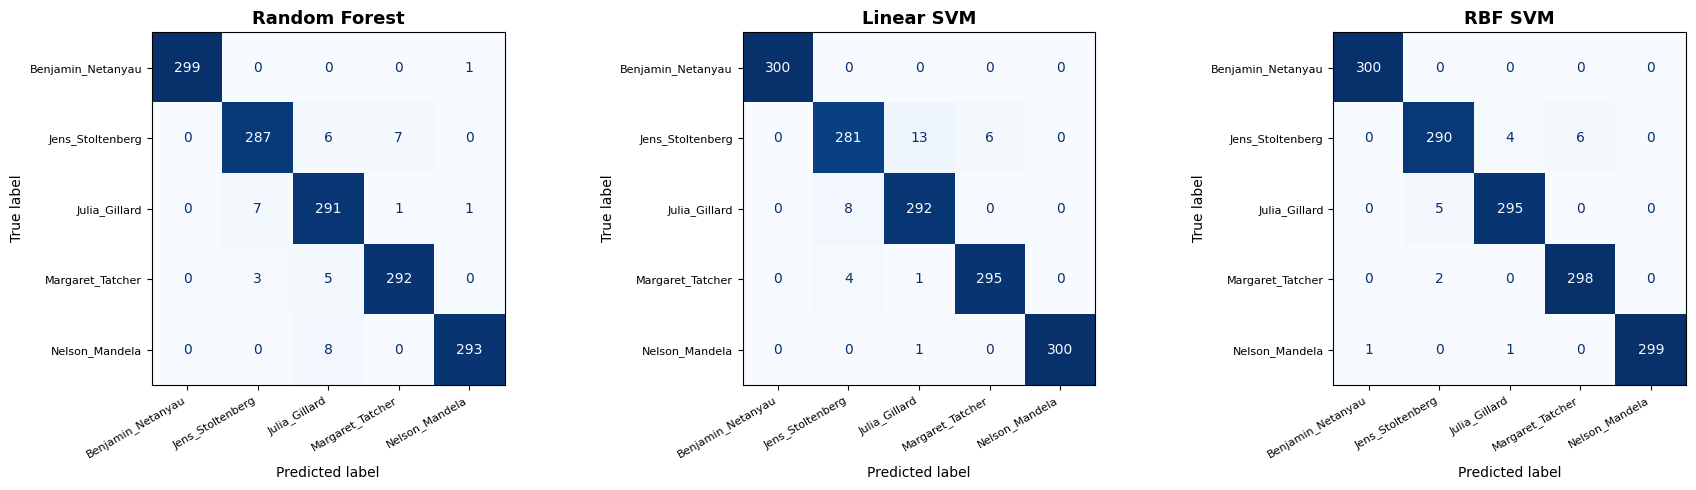

[INFO] Confusion matrix plot successfully saved to: /content/drive/MyDrive/Speech_Project/confusion_matrix.png


In [55]:
# ============================================================
# [Cell 11] Test Set: Final Performance Evaluation
# ============================================================

# Calculate accuracies using predictions from Cell 10
rf_test_acc     = accuracy_score(y_test, y_pred_rf)
linear_test_acc = accuracy_score(y_test, y_pred_linear_svm)
rbf_test_acc    = accuracy_score(y_test, y_pred_rbf_svm)

# 1. Test Set Accuracy Display
print("Test Set Model Performance Comparison")
print(f"  Random Forest                        : {rf_test_acc*100:.2f}%")
print(f"  Linear SVM                           : {linear_test_acc*100:.2f}%")
print(f"  RBF SVM (C={best_C}, gamma={best_gamma}) : {rbf_test_acc*100:.2f}%")

# 2. Detailed Classification Reports (Precision, Recall, F1-score)
for name, y_pred in [("Random Forest", y_pred_rf), ("Linear SVM", y_pred_linear_svm), ("RBF SVM", y_pred_rbf_svm)]:
    print(f"\n[Report] {name} Classification Report")
    print(classification_report(y_test, y_pred, target_names=SPEAKER_NAMES))

# 3. Confusion Matrix Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ("Random Forest", y_pred_rf),
    ("Linear SVM", y_pred_linear_svm),
    ("RBF SVM", y_pred_rbf_svm)
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SPEAKER_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")

    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xticklabels(SPEAKER_NAMES, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(SPEAKER_NAMES, fontsize=8)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/confusion_matrix.png", dpi=150)
plt.show()

print(f"[INFO] Confusion matrix plot successfully saved to: {DRIVE_DIR}/confusion_matrix.png")

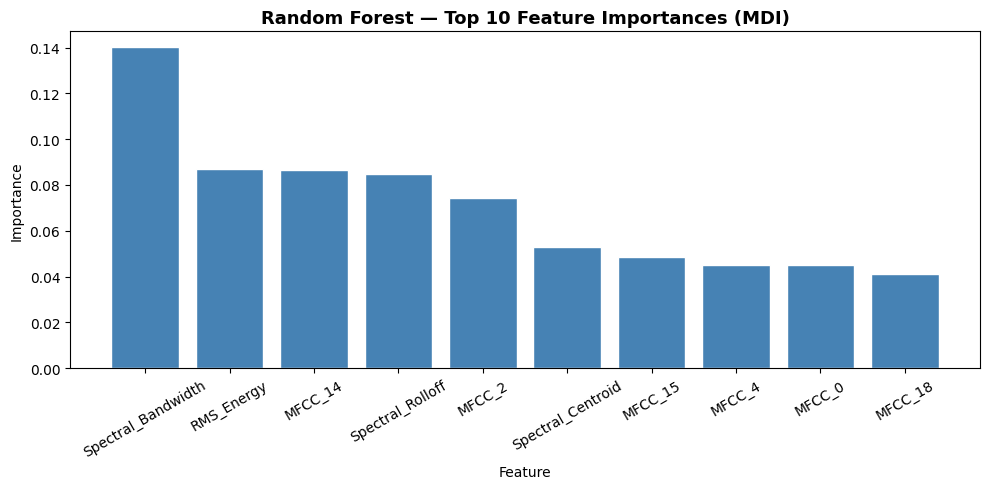

[INFO] Feature importance plot saved to: /content/drive/MyDrive/Speech_Project/feature_importance.png

[INFO] Computing t-SNE dimensionality reduction for visualization...


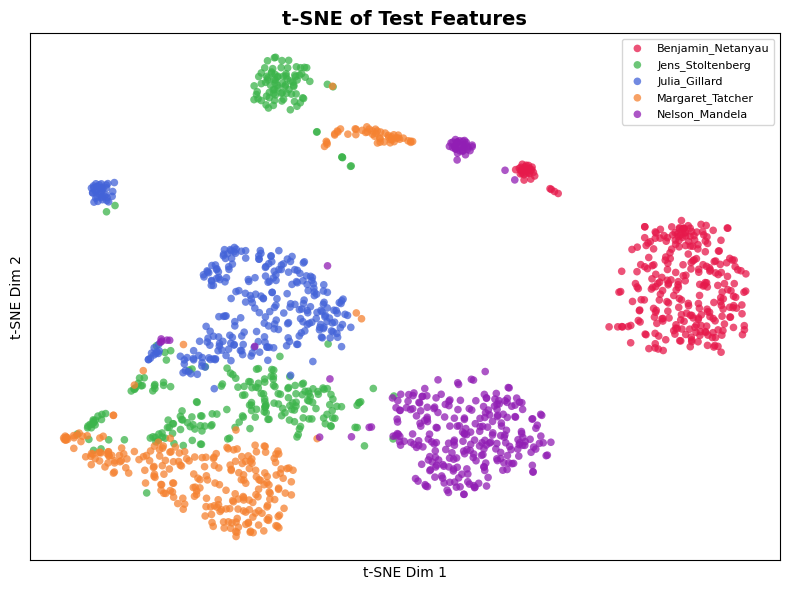

[INFO] t-SNE scatter plot successfully saved to: /content/drive/MyDrive/Speech_Project/tsne.png


In [56]:
# ============================================================
# [Cell 12] Analysis: Feature Importance & t-SNE Projection
# ============================================================

# ── Feature Labels (25 Dimensions) ───────────────────────────
feature_labels = (
    [f"MFCC_{i}" for i in range(N_MFCC)]
    + ["Spectral_Centroid", "Spectral_Rolloff", "Spectral_Bandwidth"]
    + ["Pitch_f0"]
    + ["RMS_Energy"]
)

# ── Feature Importance: Random Forest (Top 10) ───────────────
importances = rf.feature_importances_
top10_idx    = np.argsort(importances)[::-1][:10]
top10_values = importances[top10_idx]
top10_labels = [feature_labels[i] for i in top10_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top10_labels, top10_values, color="steelblue", edgecolor="white")
ax.set_title("Random Forest — Top 10 Feature Importances (MDI)", fontsize=13, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/feature_importance.png", dpi=150)
plt.show()
print(f"[INFO] Feature importance plot saved to: {DRIVE_DIR}/feature_importance.png\n")

# ── t-SNE Dimensionality Reduction ───────────────────────────
print("[INFO] Computing t-SNE dimensionality reduction for visualization...")

PALETTE = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4"]

tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for idx, name in enumerate(SPEAKER_NAMES):
    mask = y_test == idx
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        label=name, color=PALETTE[idx],
        s=30, alpha=0.75, edgecolors="none"
    )
ax.set_title("t-SNE of Test Features", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE Dim 1")
ax.set_ylabel("t-SNE Dim 2")
ax.legend(fontsize=8, loc="best")

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/tsne.png", dpi=150)
plt.show()
print(f"[INFO] t-SNE scatter plot successfully saved to: {DRIVE_DIR}/tsne.png")